<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# get updated github content
!git clone https://github.com/SiyuL2025/math_629_final.git
!cd /content/math_629_final && git pull

Cloning into 'math_629_final'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 105 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 2.92 MiB | 945.00 KiB/s, done.
Resolving deltas: 100% (27/27), done.
Already up to date.


1. DOWNLOAD AND LOAD DATA


100%|██████████| 993M/993M [00:25<00:00, 40.3MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/martinsn/high-frequency-crypto-limit-order-book-data/versions/1
BTC shape: (100000, 156)
ETH shape: (100000, 156)

2. TIME ALIGNMENT
BTC time range: 2021-04-07 11:32:42+00:00 → 2021-04-08 15:19:54+00:00
ETH time range: 2021-04-07 11:32:50+00:00 → 2021-04-08 15:19:46+00:00
After merge: (99972, 160)  (99,972 rows retained)

3. FEATURE ENGINEERING
Shape after dropna: (99902, 178)
Label distribution:
label
-1    31426
 0    37159
 1    31317

LOB features   : 60
Market features: 15

4. PCA
LOB features : 60
PCA components retained (90% variance): 30
Train PCA shape: (79921, 30)
Test  PCA shape: (19981, 30)

5. PCA DIAGNOSTICS


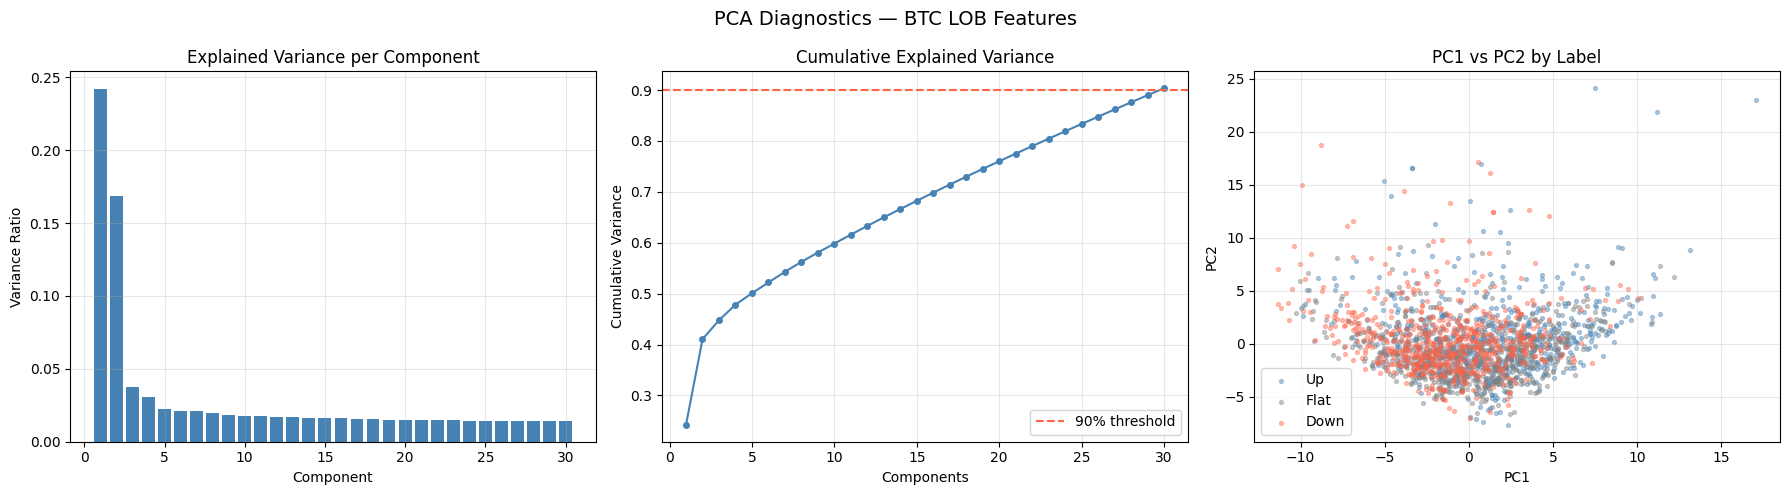


6. FINAL DATASET ASSEMBLY
X_final shape  : (99902, 45)
Y_final shape  : (99902,)

Feature breakdown:
  PCA components : 30
  Market features: 15
  Total          : 45

Train / Test split index: 79921


,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,...,btc_momentum_60s,eth_spread,eth_oimb_1,eth_volatility_10s,eth_volatility_60s,eth_momentum_10s,eth_momentum_60s,btc_eth_momentum_diff_10s,btc_eth_momentum_diff_60s,btc_eth_vol_ratio_10s
0,1.997145,7.441477,0.048101,1.310962,-1.132676,1.936455,0.292069,-0.853289,0.310951,-0.382409,...,-0.003200,0.01,-0.396305,0.000207,0.000253,-0.000506,-0.002474,-0.000195,-0.000726,1.028826
1,-3.522458,7.080465,-2.195006,0.526237,-2.140027,2.047595,0.519002,1.086173,0.014582,0.268709,...,-0.003156,0.39,-0.679389,0.000199,0.000253,-0.000605,-0.002443,-0.000055,-0.000713,1.076590
2,2.390608,9.200963,4.302600,1.919440,-2.437481,0.735135,-0.235451,0.792108,-0.357739,1.224468,...,-0.003354,0.03,0.522530,0.000204,0.000253,-0.000389,-0.002347,-0.000442,-0.001007,1.068719
3,-5.630498,13.420166,-3.047943,-0.564960,-0.783937,-0.654891,-0.354128,-1.107642,-0.806801,0.383663,...,-0.003425,0.36,-0.196982,0.000167,0.000253,-0.000114,-0.002456,-0.000544,-0.000969,1.256562
4,-6.412811,12.154399,-1.252472,0.173083,-1.683628,0.688104,0.254088,-0.199066,0.376749,1.433366,...,-0.003336,0.21,0.704133,0.000168,0.000253,-0.000043,-0.002489,-0.000218,-0.000847,1.169641


In [4]:
# import data
import sys
sys.path.append('./math_629_final')

import BTC_ETH_pipeline

In [18]:
import math, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ╔══════════════════════════════════════════════════════════════════╗
# ║              ★  CHOOSE YOUR INPUTS HERE  ★                      ║
# ║                                                                  ║
# ║  FEATURE_SET:                                                    ║
# ║    "full"  → PCA components + ALL market features                ║
# ║              (BTC + ETH + cross-asset, i.e. X_final)            ║
# ║    "pca"   → PCA components only  (no market features)           ║
# ║    "raw"   → original 60 BTC LOB features (no PCA, no market)   ║
# ║                                                                  ║
# ║  TRANSACTION_COST: one-way cost per trade (e.g. 0.0005 = 5bps)  ║
# ╚══════════════════════════════════════════════════════════════════╝
# FEATURE_SET      = "raw"      ← change me: "full" | "pca" | "raw"
# TRANSACTION_COST = 0.0005     ← change me: one-way cost per trade

# ── Config ────────────────────────────────────────────────────────────────────
SEED       = 42
SEQ_LEN    = 30
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 3
D_FF       = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 30
LR         = 3e-4
PATIENCE   = 6

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Feature Selection
# ══════════════════════════════════════════════════════════════════════════════
def select_features(feature_set: str):
    """
    "full" → X_final  (PCA cols + BTC market + ETH market + cross-asset features)
    "pca"  → PCA columns only  (columns starting with 'pca_')
    "raw"  → 60 original BTC LOB features from df  (no PCA, no market)
    """
    if feature_set == "full":
        print("Feature set : FULL  (PCA + BTC/ETH market state + cross-asset)")
        X = BTC_ETH_pipeline.X_final.values.astype(np.float32)

    elif feature_set == "pca":
        pca_cols = [c for c in BTC_ETH_pipeline.X_final.columns if c.startswith("pca_")]
        print(f"Feature set : PCA only  ({len(pca_cols)} components)")
        X = BTC_ETH_pipeline.X_final[pca_cols].values.astype(np.float32)

    elif feature_set == "raw":
        lob_cols = []
        for i in range(15):
            lob_cols += [f"bids_distance_{i}", f"asks_distance_{i}",
                         f"bids_notional_{i}", f"asks_notional_{i}"]
        print(f"Feature set : RAW BTC LOB  ({len(lob_cols)} features, no PCA, no market)")
        X = BTC_ETH_pipeline.df[lob_cols].values.astype(np.float32)

    else:
        raise ValueError(f"Unknown feature_set '{feature_set}'. Choose 'full', 'pca', or 'raw'.")

    y = (BTC_ETH_pipeline.Y_final.values + 1).astype(np.int64)   # {-1, 0, 1} → {0, 1, 2}
    print(f"X shape : {X.shape}  |  y shape : {y.shape}")
    print(f"Label dist — Down:{(y==0).sum():,}  Flat:{(y==1).sum():,}  Up:{(y==2).sum():,}")
    return X, y


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Dataset & DataLoaders
# ══════════════════════════════════════════════════════════════════════════════
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X, y):
    """Chronological 80/20 split → normalise → sliding-window DataLoaders."""
    split  = int(len(X) * 0.8)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])
    X_te   = scaler.transform(X[split:])
    y_tr, y_te = y[:split], y[split:]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}  |  "
          f"Test samples : {len(test_loader.dataset):,}")
    print(f"Class weights (down/flat/up) : {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w, split


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Model
# ══════════════════════════════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class LOBTransformer(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.proj    = nn.Linear(n_features, D_MODEL)
        self.pos_enc = PositionalEncoding(D_MODEL, dropout=DROPOUT)
        enc_layer    = nn.TransformerEncoderLayer(
            D_MODEL, N_HEADS, D_FF, DROPOUT,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))
        self.head    = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, 3)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pos_enc(self.proj(x))    # (B, T, D_MODEL)
        x = self.encoder(x).mean(dim=1)   # mean-pool over time
        return self.head(x)


def build_model(n_features):
    model    = LOBTransformer(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model params : {n_params:,}  |  Input features : {n_features}")
    return model


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Training
# ══════════════════════════════════════════════════════════════════════════════
def train(model, train_loader, test_loader, class_w):
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval(); vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        val_loss = vloss / total
        val_acc  = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Ep {epoch:3d}/{EPOCHS} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
                break

    model.load_state_dict(best_state)
    return history, best_acc


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Prediction
# ══════════════════════════════════════════════════════════════════════════════
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            all_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6.1 — Statistical Prediction Metrics
# ══════════════════════════════════════════════════════════════════════════════
def statistical_metrics(y_true, y_pred):
    """
    Evaluates classification accuracy, precision, recall, and F1-score
    for the Down, Flat, and Up classes.
    """
    print("\n" + "=" * 60)
    print("  6.1  STATISTICAL PREDICTION METRICS")
    print("=" * 60)

    acc = (y_pred == y_true).mean()
    print(f"\nOverall Accuracy : {acc:.4f}  ({acc*100:.2f}%)\n")

    target_names = ["Down (-1)", "Flat (0)", "Up (+1)"]
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-" * 46)
    for i, name in enumerate(target_names):
        print(f"{name:<12} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {sup[i]:>10,}")

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, support=sup)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6.2 — Economic Evaluation & Backtesting
# ══════════════════════════════════════════════════════════════════════════════
def backtest(y_pred, split_idx, transaction_cost=0.0005):
    """
    Simple long / short / neutral strategy on the test set.

    Signal mapping (predictions in {0, 1, 2}):
      0 (Down) → short  (-1)
      1 (Flat) → hold    (0)
      2 (Up)   → long   (+1)

    Actual log-returns are taken from BTC_ETH_pipeline.df['log_return']
    aligned to the test window. Transaction cost is charged on every
    position change.

    Performance metrics reported:
      - Cumulative return
      - Annualised Sharpe ratio
      - Maximum drawdown
      - Total trades & turnover
    """
    print("\n" + "=" * 60)
    print("  6.2  ECONOMIC EVALUATION & BACKTESTING")
    print("=" * 60)

    # ── Align actual log-returns to the test window ───────────────────────────
    # Sliding window of SEQ_LEN means the first valid prediction corresponds
    # to index (split_idx + SEQ_LEN - 1) in the original series.
    log_ret_full = BTC_ETH_pipeline.df['log_return'].values
    test_start   = split_idx + SEQ_LEN - 1
    test_end     = test_start + len(y_pred)
    actual_ret   = log_ret_full[test_start:test_end].astype(np.float64)

    # ── Positions ─────────────────────────────────────────────────────────────
    signal_map = {0: -1, 1: 0, 2: 1}
    positions  = np.array([signal_map[p] for p in y_pred], dtype=np.float64)

    # ── Transaction costs — charged on every position change ──────────────────
    trade_mask  = (np.diff(positions, prepend=0) != 0).astype(float)
    cost_series = trade_mask * transaction_cost

    # ── Strategy vs buy-and-hold returns ──────────────────────────────────────
    strat_ret = positions * actual_ret - cost_series
    bh_ret    = actual_ret

    cum_strat = np.cumprod(1 + strat_ret) - 1
    cum_bh    = np.cumprod(1 + bh_ret)   - 1

    # ── Annualised Sharpe ratio ───────────────────────────────────────────────
    # 1-second bars: 252 trading days × 23,400 seconds per day
    BARS_PER_YEAR = 252 * 23_400
    sr_strat = (strat_ret.mean() / (strat_ret.std() + 1e-8)) * np.sqrt(BARS_PER_YEAR)
    sr_bh    = (bh_ret.mean()    / (bh_ret.std()    + 1e-8)) * np.sqrt(BARS_PER_YEAR)

    # ── Maximum drawdown ──────────────────────────────────────────────────────
    def max_drawdown(cum):
        equity = 1 + cum
        peak   = np.maximum.accumulate(equity)
        return ((equity - peak) / (peak + 1e-8)).min()

    mdd_strat = max_drawdown(cum_strat)
    mdd_bh    = max_drawdown(cum_bh)

    # ── Turnover ──────────────────────────────────────────────────────────────
    n_trades = int(trade_mask.sum())
    turnover = trade_mask.mean()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Metric':<30} {'Strategy':>12} {'Buy & Hold':>12}")
    print("-" * 56)
    print(f"{'Cumulative Return':<30} {cum_strat[-1]:>12.4f} {cum_bh[-1]:>12.4f}")
    print(f"{'Annualised Sharpe Ratio':<30} {sr_strat:>12.4f} {sr_bh:>12.4f}")
    print(f"{'Maximum Drawdown':<30} {mdd_strat:>12.4f} {mdd_bh:>12.4f}")
    print(f"{'Total Trades':<30} {n_trades:>12,} {'—':>12}")
    print(f"{'Turnover (per bar)':<30} {turnover:>12.4f} {'—':>12}")
    print(f"{'Transaction Cost (one-way)':<30} {transaction_cost:>12.4f} {'—':>12}")

    bt_metrics = dict(
        cum_return_strat   = cum_strat[-1],
        cum_return_bh      = cum_bh[-1],
        sharpe_strat       = sr_strat,
        sharpe_bh          = sr_bh,
        max_drawdown_strat = mdd_strat,
        max_drawdown_bh    = mdd_bh,
        n_trades           = n_trades,
        turnover           = turnover,
    )
    return bt_metrics, cum_strat, cum_bh, strat_ret


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Plots
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(history, y_pred, y_true, cum_strat, cum_bh, strat_ret, title=""):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Transformer LOB — {title}", fontsize=15)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── Row 0 : training diagnostics ─────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ep  = range(1, len(history["train_loss"]) + 1)
    ax0.plot(ep, history["train_loss"], label="Train", color="steelblue")
    ax0.plot(ep, history["val_loss"],   label="Val",   color="tomato")
    ax0.set_title("Training Loss"); ax0.legend(); ax0.grid(alpha=0.3)
    ax0.set_xlabel("Epoch"); ax0.set_ylabel("Cross-Entropy Loss")

    ax1 = fig.add_subplot(gs[0, 1])
    best = max(history["val_acc"])
    ax1.plot(ep, history["val_acc"], color="seagreen")
    ax1.axhline(best, color="tomato", linestyle="--", label=f"Best={best:.4f}")
    ax1.set_title("Validation Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")

    ax2 = fig.add_subplot(gs[0, 2])
    cm  = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2,
                xticklabels=["Down", "Flat", "Up"],
                yticklabels=["Down", "Flat", "Up"])
    ax2.set_title("Confusion Matrix")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")

    # ── Row 1 : economic evaluation ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.plot(cum_strat * 100, label="Strategy",       color="steelblue", linewidth=1.2)
    ax3.plot(cum_bh    * 100, label="Buy & Hold BTC", color="tomato",
             linewidth=1.0, linestyle="--", alpha=0.8)
    ax3.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax3.set_title("Cumulative Return — Strategy vs Buy & Hold")
    ax3.set_xlabel("Test Bar (1-second intervals)")
    ax3.set_ylabel("Cumulative Return (%)")
    ax3.legend(); ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])
    W        = 500
    r_mu     = np.convolve(strat_ret, np.ones(W) / W, mode="valid")
    r_std    = np.array([strat_ret[i:i+W].std() for i in range(len(strat_ret) - W + 1)])
    ax4.plot(r_mu / (r_std + 1e-8) * np.sqrt(252 * 23_400),
             color="darkorchid", linewidth=0.9)
    ax4.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax4.set_title(f"Rolling Sharpe Ratio ({W}-bar window)")
    ax4.set_xlabel("Test Bar"); ax4.set_ylabel("Sharpe Ratio")
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — Full Pipeline
# ══════════════════════════════════════════════════════════════════════════════
def run_transformer(feature_set: str, transaction_cost: float = 0.0005):
    """
    End-to-end pipeline: select features → train → 6.1 statistical metrics
                         → 6.2 backtesting → plots.

    Parameters
    ----------
    feature_set      : "full" | "pca" | "raw"
    transaction_cost : one-way cost per trade (default 5 bps)

    Reads from notebook scope: BTC_ETH_pipeline (holds df, X_final, Y_final)
    """
    print("=" * 60)
    print(f"  Transformer LOB  |  feature_set='{feature_set}'  |  cost={transaction_cost}")
    print("=" * 60)

    X, y                              = select_features(feature_set)
    train_ld, test_ld, class_w, split = build_loaders(X, y)
    model                             = build_model(n_features=X.shape[1])

    print("\n--- Training ---")
    history, best_acc = train(model, train_ld, test_ld, class_w)

    print("\n--- Prediction ---")
    y_pred, y_true = evaluate(model, test_ld)

    # 6.1 Statistical prediction metrics
    stat_metrics = statistical_metrics(y_true, y_pred)

    # 6.2 Economic evaluation & backtesting
    bt_metrics, cum_strat, cum_bh, strat_ret = backtest(
        y_pred, split_idx=split, transaction_cost=transaction_cost
    )

    plot_results(
        history, y_pred, y_true, cum_strat, cum_bh, strat_ret,
        title=f"feature_set='{feature_set}'  |  best val acc={best_acc:.4f}"
    )

    return model, history, stat_metrics, bt_metrics


# ══════════════════════════════════════════════════════════════════════════════
#  ★  ENTRY POINT
#     • Single run  : change FEATURE_SET / TRANSACTION_COST at the top
#     • Compare all : uncomment the three lines below
# ══════════════════════════════════════════════════════════════════════════════

# --- compare all three feature sets ---
# m1, h1, s1, b1 = run_transformer("full", TRANSACTION_COST)
# m2, h2, s2, b2 = run_transformer("pca",  TRANSACTION_COST)
# m3, h3, s3, b3 = run_transformer("raw",  TRANSACTION_COST)

Device: cuda


  Transformer LOB  |  feature_set='raw'  |  cost=0.0005
Feature set : RAW BTC LOB  (60 features, no PCA, no market)
X shape : (99902, 60)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 106,627  |  Input features : 60

--- Training ---


/tmp/ipykernel_2559/3041664160.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0829 | Val Loss 1.0574 | Val Acc 0.4389
Ep   2/30 | Train Loss 1.0571 | Val Loss 1.0281 | Val Acc 0.4754
Ep   3/30 | Train Loss 1.0383 | Val Loss 1.0100 | Val Acc 0.4848
Ep   4/30 | Train Loss 1.0269 | Val Loss 1.0038 | Val Acc 0.4914
Ep   5/30 | Train Loss 1.0212 | Val Loss 1.0000 | Val Acc 0.4967
Ep   6/30 | Train Loss 1.0154 | Val Loss 0.9978 | Val Acc 0.4988
Ep   7/30 | Train Loss 1.0116 | Val Loss 0.9955 | Val Acc 0.5010
Ep   8/30 | Train Loss 1.0069 | Val Loss 0.9950 | Val Acc 0.5036
Ep   9/30 | Train Loss 1.0026 | Val Loss 0.9955 | Val Acc 0.5014
Ep  10/30 | Train Loss 0.9988 | Val Loss 0.9952 | Val Acc 0.5016
Ep  11/30 | Train Loss 0.9938 | Val Loss 0.9978 | Val Acc 0.5002
Ep  12/30 | Train Loss 0.9899 | Val Loss 0.9991 | Val Acc 0.4965
Ep  13/30 | Train Loss 0.9863 | Val Loss 1.0015 | Val Acc 0.4959
Ep  14/30 | Train Loss 0.9821 | Val Loss 1.0035 | Val Acc 0.4955
Early stop at epoch 14. Best val acc: 0.5036

--- Prediction ---

  6.1  STATISTICAL PREDI

/tmp/ipykernel_2559/3041664160.py:407: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


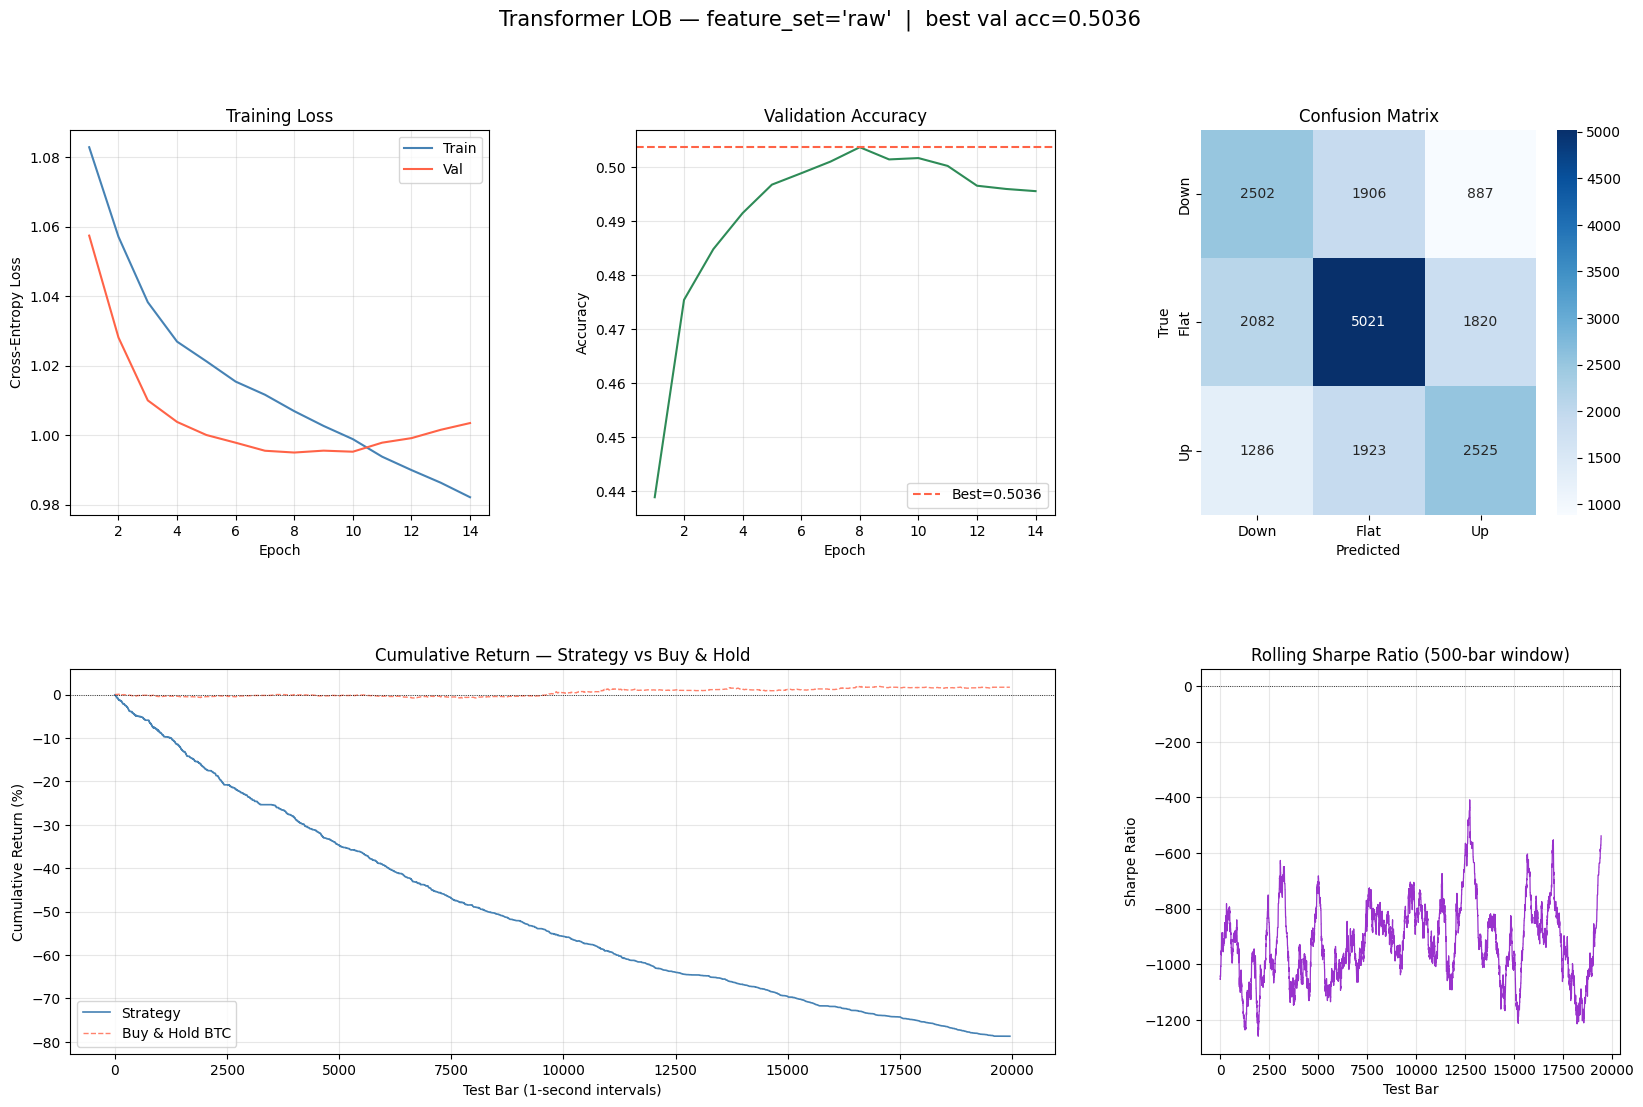

In [23]:
FEATURE_SET = "raw"
TRANSACTION_COST = 0.0005
model, history, stat_metrics, bt_metrics = run_transformer(FEATURE_SET, TRANSACTION_COST)

  Transformer LOB  |  feature_set='pca'  |  cost=0.0005
Feature set : PCA only  (30 components)
X shape : (99902, 30)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 104,707  |  Input features : 30

--- Training ---


/tmp/ipykernel_2559/3041664160.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0891 | Val Loss 1.0625 | Val Acc 0.4472
Ep   2/30 | Train Loss 1.0651 | Val Loss 1.0230 | Val Acc 0.4761
Ep   3/30 | Train Loss 1.0417 | Val Loss 1.0061 | Val Acc 0.4946
Ep   4/30 | Train Loss 1.0329 | Val Loss 1.0016 | Val Acc 0.5004
Ep   5/30 | Train Loss 1.0286 | Val Loss 0.9993 | Val Acc 0.5015
Ep   6/30 | Train Loss 1.0240 | Val Loss 0.9966 | Val Acc 0.5031
Ep   7/30 | Train Loss 1.0212 | Val Loss 0.9972 | Val Acc 0.5037
Ep   8/30 | Train Loss 1.0180 | Val Loss 0.9977 | Val Acc 0.5025
Ep   9/30 | Train Loss 1.0151 | Val Loss 0.9998 | Val Acc 0.5032
Ep  10/30 | Train Loss 1.0119 | Val Loss 0.9989 | Val Acc 0.5018
Ep  11/30 | Train Loss 1.0086 | Val Loss 1.0015 | Val Acc 0.5021
Ep  12/30 | Train Loss 1.0059 | Val Loss 1.0046 | Val Acc 0.4980
Ep  13/30 | Train Loss 1.0026 | Val Loss 1.0030 | Val Acc 0.4990
Early stop at epoch 13. Best val acc: 0.5037

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy : 0.5037  (50.37%)

             

/tmp/ipykernel_2559/3041664160.py:407: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


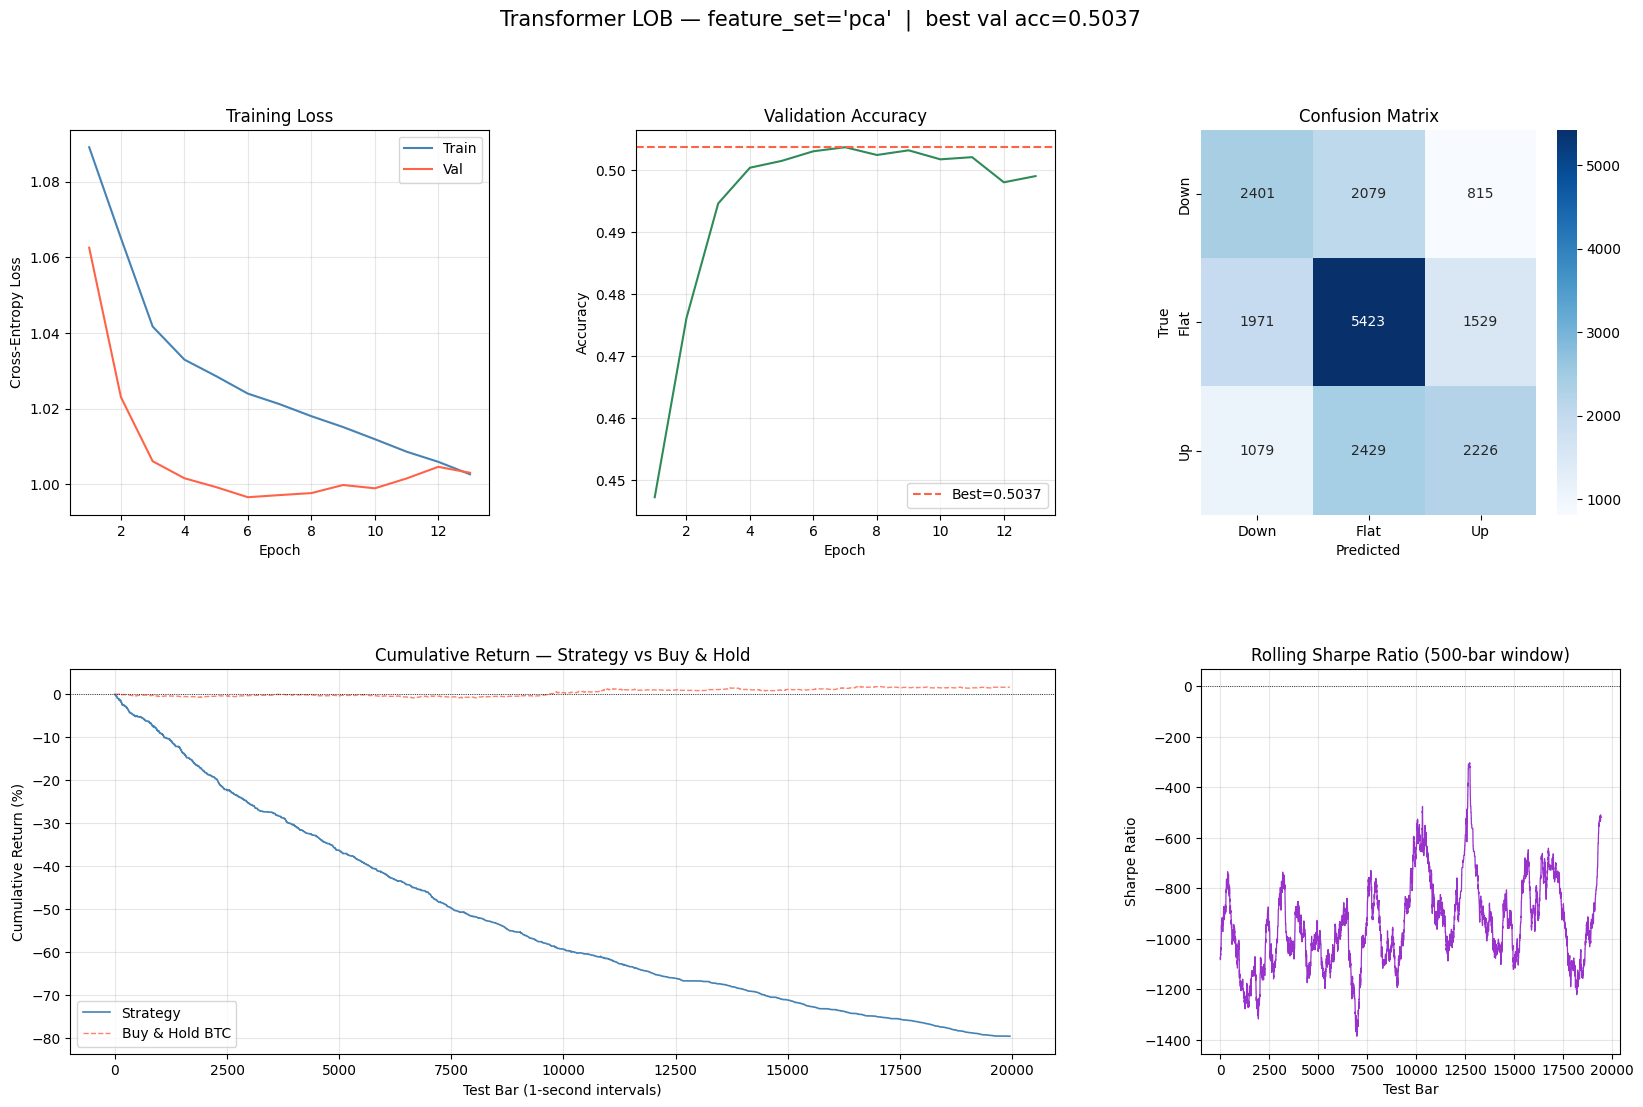

In [19]:
# pca model
FEATURE_SET = "pca"
TRANSACTION_COST = 0.0005
model, history, stat_metrics, bt_metrics = run_transformer(FEATURE_SET, TRANSACTION_COST)

  Transformer LOB  |  feature_set='full'  |  cost=0.0005
Feature set : FULL  (PCA + BTC/ETH market state + cross-asset)
X shape : (99902, 45)  |  y shape : (99902,)
Label dist — Down:31,426  Flat:37,159  Up:31,317
Train samples : 79,892  |  Test samples : 19,952
Class weights (down/flat/up) : [1.02  0.944 1.042]
Model params : 105,667  |  Input features : 45

--- Training ---


/tmp/ipykernel_2559/3041664160.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0769 | Val Loss 1.0435 | Val Acc 0.4757
Ep   2/30 | Train Loss 1.0414 | Val Loss 1.0022 | Val Acc 0.4993
Ep   3/30 | Train Loss 1.0157 | Val Loss 0.9856 | Val Acc 0.5097
Ep   4/30 | Train Loss 1.0055 | Val Loss 0.9803 | Val Acc 0.5148
Ep   5/30 | Train Loss 1.0004 | Val Loss 0.9775 | Val Acc 0.5185
Ep   6/30 | Train Loss 0.9956 | Val Loss 0.9776 | Val Acc 0.5183
Ep   7/30 | Train Loss 0.9915 | Val Loss 0.9778 | Val Acc 0.5171
Ep   8/30 | Train Loss 0.9882 | Val Loss 0.9778 | Val Acc 0.5152
Ep   9/30 | Train Loss 0.9845 | Val Loss 0.9790 | Val Acc 0.5140
Ep  10/30 | Train Loss 0.9803 | Val Loss 0.9793 | Val Acc 0.5131
Ep  11/30 | Train Loss 0.9754 | Val Loss 0.9811 | Val Acc 0.5115
Early stop at epoch 11. Best val acc: 0.5185

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy : 0.5185  (51.85%)

              precision    recall  f1-score   support

   Down (-1)     0.4384    0.4648    0.4512      5295
    Flat (0)     0.5741    0.5863 

/tmp/ipykernel_2559/3041664160.py:407: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


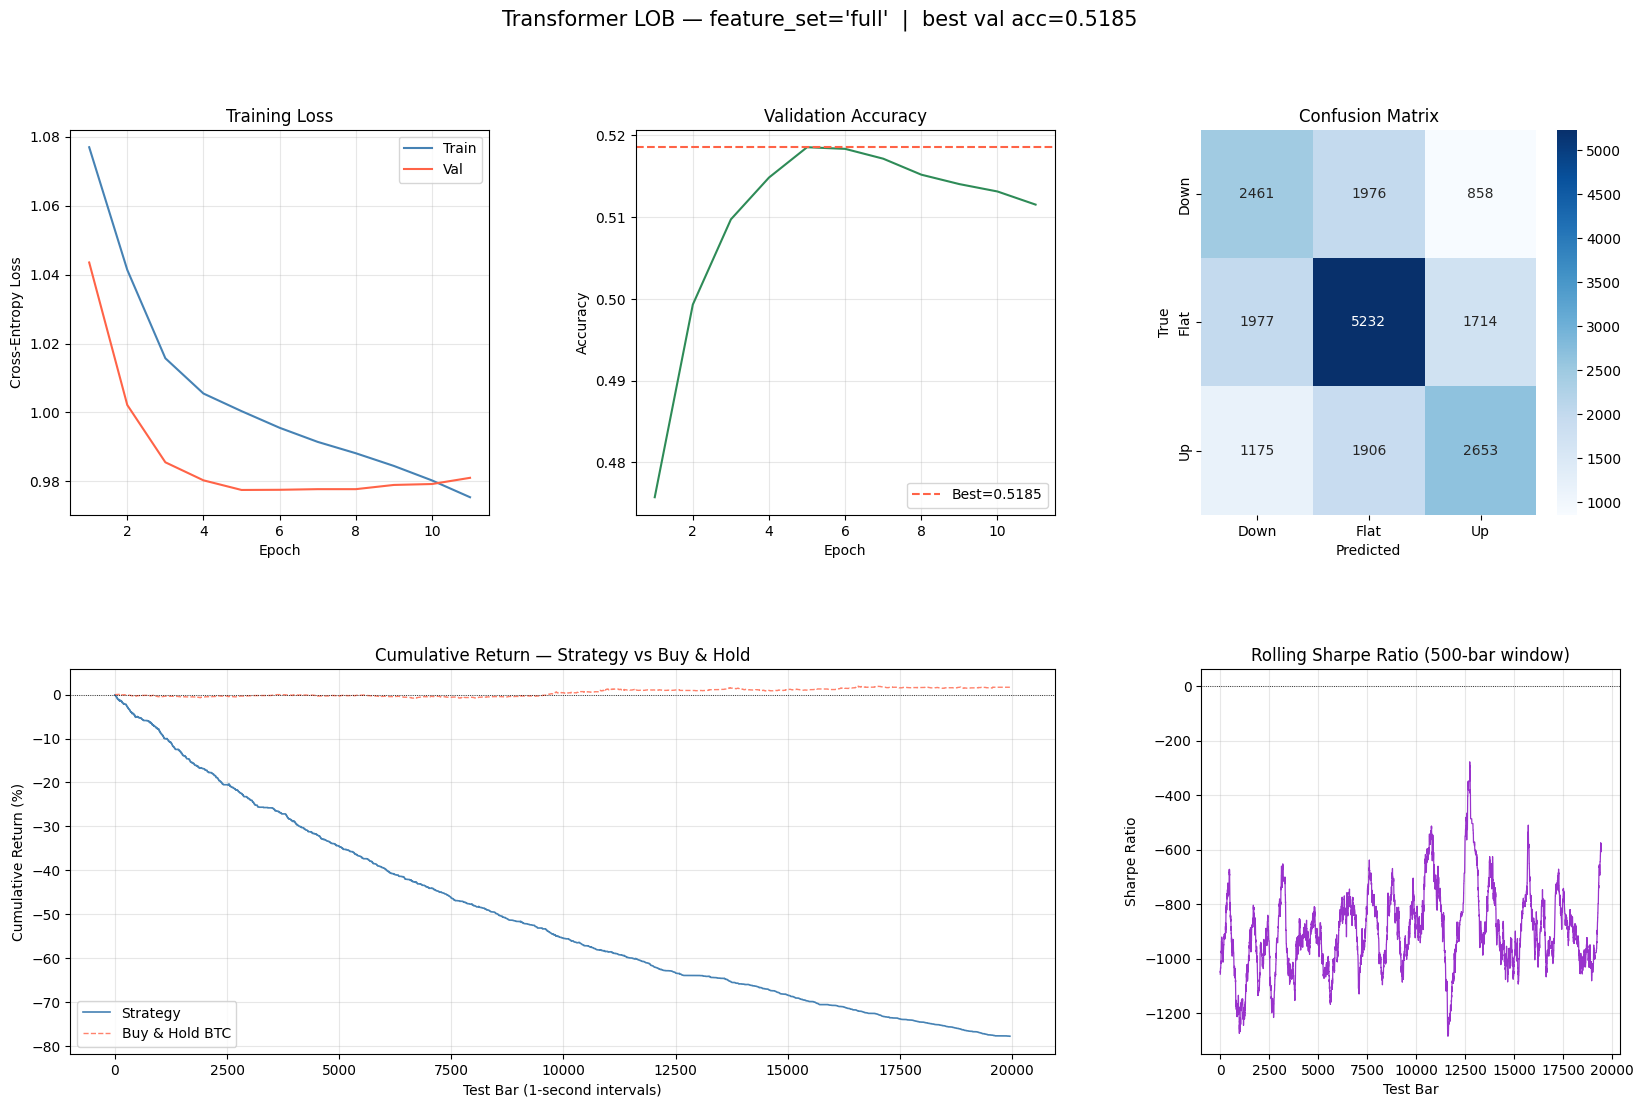

In [25]:
# pca model plus market facotrs
FEATURE_SET = "full"
TRANSACTION_COST = 0.0005
model, history, stat_metrics, bt_metrics = run_transformer(FEATURE_SET, TRANSACTION_COST)